# Single Task Visualization - Voltage Sweep

Same approach as TSMC training: 2 support voltages → 1 query voltage within same (Corner, Temp)

**Groups:**
- FF @ -40C: 0.88V, 0.99V, 1.1V
- FF @ 125C: 0.88V, 0.99V, 1.1V
- SS @ -40C: 0.72V, 0.81V, 0.9V
- SS @ 125C: 0.72V, 0.81V, 0.9V
- TT @ 25C: 0.8V, 0.9V, 1.0V

In [104]:
import os
import sys
import torch
import torch.nn as nn
import numpy as np
import random
import re
import matplotlib.pyplot as plt
from pathlib import Path
from collections import OrderedDict, defaultdict

# Add paths
sys.path.insert(0, '/home/tkdgn2907/Deepsets_test/MAML/Projects/model_code')
from maml_optimized import OptimizedMAML, MAMLModel_3hidden

In [105]:
# ============================================================
# CONFIGURATION
# ============================================================

DATA_DIR = '/home/tkdgn2907/Deepsets_test/MAML/Projects/CAD_TEST/AND_cells_extracted'
MODEL_PATH = '/home/tkdgn2907/Deepsets_test/MAML/Projects/pretrained_models/training_loss_taskdivide_all/cell_innerdiv100_meta32_combined_519traintask_full1DMAML_weights_3hidden_(40)_300000_inner1_upgraded_tsmc.pth'
TSMC_TRAIN_INPUT_PATH = '/home/tkdgn2907/Deepsets_test/MAML/Projects/dataset_all/MLP_dataset_TSMC/combined_data/tsmc_topology_agnostic_train_input_cell.pth'

GPU_ID = '0'
RANDOM_TASK_ID = None  # Set to specific number or None for random

# Voltage sweep groups: (corner, temp) -> [conditions sorted by voltage]
VOLTAGE_SWEEP_GROUPS = {
    ('FF', -40): ['ff0p88vm40c', 'ff0p99vm40c', 'ff1p1vm40c'],      # 0.88V, 0.99V, 1.1V
    ('FF', 125): ['ff0p88v125c', 'ff0p99v125c', 'ff1p1v125c'],      # 0.88V, 0.99V, 1.1V
    ('SS', -40): ['ss0p72vm40c', 'ss0p81vm40c', 'ss0p9vm40c'],      # 0.72V, 0.81V, 0.9V
    ('SS', 125): ['ss0p72v125c', 'ss0p81v125c', 'ss0p9v125c'],      # 0.72V, 0.81V, 0.9V
    ('TT', 25):  ['tt0p8v25c', 'tt0p9v25c', 'tt1p0v25c'],           # 0.8V, 0.9V, 1.0V
}

# Scenario: which voltages for support/query
# 'interpolate': low & high -> middle
# 'extrapolate_high': low & mid -> high
# 'extrapolate_low': mid & high -> low
SCENARIO = 'interpolate'  # Change this!

SCENARIOS = {
    'interpolate': {'support': [0, 2], 'query': 1},
    'extrapolate_high': {'support': [0, 1], 'query': 2},
    'extrapolate_low': {'support': [1, 2], 'query': 0},
}

# TSMC Process Parameters
PARAM_A = [1.427, 1.457, 1.430, 1.470, 1.443, 1.483, 1.43, 1.47, 1.43, 1.47]
PARAM_B = [0.026, 0.045, 0, 0, -0.026, -0.05, 0.0208, -0.04, 0.036, -0.0208]
PARAM_C = [0.024, 2.000, 0.024, 2.000, 0.024, 2.000, 0.024, 2.000, 0.024, 2.000]
CORNER_TO_IDX = {'FF': 0, 'TT': 1, 'SS': 2, 'FS': 3, 'SF': 4}

In [106]:
# GPU settings
os.environ["CUDA_VISIBLE_DEVICES"] = GPU_ID
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Device: {device}')

Device: cuda


In [107]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def parse_filename(filename):
    match = re.search(r'(ff|tt|ss|fs|sf)(\d+p\d+)v(m?\d+)c', filename.lower())
    if not match:
        raise ValueError(f"Cannot parse filename: {filename}")
    corner = match.group(1).upper()
    voltage = float(match.group(2).replace('p', '.'))
    temp_str = match.group(3)
    temperature = -float(temp_str[1:]) if temp_str.startswith('m') else float(temp_str)
    return corner, voltage, temperature

def get_abc_params(corner):
    idx = CORNER_TO_IDX.get(corner.upper(), 1)
    nmos_idx, pmos_idx = idx * 2, idx * 2 + 1
    return {'a_n': PARAM_A[nmos_idx], 'a_p': PARAM_A[pmos_idx],
            'b_n': PARAM_B[nmos_idx], 'b_p': PARAM_B[pmos_idx],
            'c_n': PARAM_C[nmos_idx], 'c_p': PARAM_C[pmos_idx]}

def parse_lib_file(lib_path):
    with open(lib_path, 'r') as f:
        content = f.read()
    samples = []
    for cell_match in re.finditer(r'cell\s*\((\w+)\)\s*\{', content):
        cell_name = cell_match.group(1)
        cell_start = cell_match.end()
        brace_count = 1
        for i in range(cell_start, len(content)):
            if content[i] == '{': brace_count += 1
            elif content[i] == '}':
                brace_count -= 1
                if brace_count == 0:
                    cell_end = i
                    break
        cell_content = content[cell_start:cell_end]
        for timing_match in re.finditer(r'timing\s*\(\)\s*\{\s*related_pin\s*:\s*"(\w+)"', cell_content):
            related_pin = timing_match.group(1)
            timing_start = timing_match.end()
            t_brace = 1
            for i in range(timing_start, len(cell_content)):
                if cell_content[i] == '{': t_brace += 1
                elif cell_content[i] == '}':
                    t_brace -= 1
                    if t_brace == 0:
                        timing_end = i
                        break
            timing_content = cell_content[timing_start:timing_end]
            for delay_type in ['cell_rise', 'cell_fall']:
                table_match = re.search(rf'{delay_type}\s*\([^)]+\)\s*\{{', timing_content)
                if table_match:
                    table_start = table_match.end()
                    tb = 1
                    for i in range(table_start, len(timing_content)):
                        if timing_content[i] == '{': tb += 1
                        elif timing_content[i] == '}':
                            tb -= 1
                            if tb == 0:
                                table_end = i
                                break
                    table_content = timing_content[table_start:table_end]
                    idx1 = re.search(r'index_1\s*\(\s*"([^"]+)"\s*\)', table_content)
                    idx2 = re.search(r'index_2\s*\(\s*"([^"]+)"\s*\)', table_content)
                    vals = re.search(r'values\s*\(\s*(.*?)\s*\)\s*;', table_content, re.DOTALL)
                    if idx1 and idx2 and vals:
                        index_1 = [float(x.strip()) for x in idx1.group(1).split(',')]
                        index_2 = [float(x.strip()) for x in idx2.group(1).split(',')]
                        values_str = vals.group(1).replace('\\', '').replace('\n', ' ')
                        rows = re.findall(r'"([^"]+)"', values_str)
                        values = [[float(x.strip()) for x in row.split(',')] for row in rows]
                        samples.append({'cell_name': cell_name, 'delay_type': delay_type,
                                       'related_pin': related_pin, 'index_1': index_1,
                                       'index_2': index_2, 'values': values})
    return samples

def create_mlp_input(samples, corner, voltage, temperature):
    abc_params = get_abc_params(corner)
    inputs, outputs, metadata = [], [], []
    for sample in samples:
        if sample['delay_type'] not in ['cell_rise', 'cell_fall']:
            continue
        delay_indicator = -1 if 'rise' in sample['delay_type'] else 1
        a = (abc_params['a_n'] + abc_params['a_p']) / 2
        b = abc_params['b_n'] + abc_params['b_p']
        c = abc_params['c_n'] + abc_params['c_p']
        for ri, slew in enumerate(sample['index_1']):
            for ci, load in enumerate(sample['index_2']):
                if ri < len(sample['values']) and ci < len(sample['values'][ri]):
                    inputs.append([a, b, c, temperature, voltage, 2, delay_indicator, slew, load])
                    outputs.append([sample['values'][ri][ci]])
                    metadata.append({'cell_name': sample['cell_name'], 'delay_type': sample['delay_type'],
                                    'related_pin': sample['related_pin'], 'slew_idx': ri, 'load_idx': ci,
                                    'slew': slew, 'load': load})
    return (torch.tensor(inputs, dtype=torch.float32),
            torch.tensor(outputs, dtype=torch.float32), metadata) if inputs else (torch.tensor([]), torch.tensor([]), [])

In [108]:
# ============================================================
# LOAD ALL DATA
# ============================================================

print("Loading data...")
base_path = Path(DATA_DIR)
all_data = {}

for voltage_dir in ['0p8v', '0p9v', '1p0v']:
    dir_path = base_path / voltage_dir
    if not dir_path.exists():
        continue
    for lib_file in sorted(dir_path.glob('AND_*.tlib')):
        match = re.search(r'AND_lib1_(\w+)_base_400\.tlib', lib_file.name)
        if not match:
            continue
        condition = match.group(1)
        corner, voltage, temperature = parse_filename(lib_file.name)
        samples = parse_lib_file(str(lib_file))
        inputs, outputs, metadata = create_mlp_input(samples, corner, voltage, temperature)
        if len(inputs) > 0:
            all_data[condition] = (inputs, outputs, metadata, corner, voltage, temperature)
            print(f"  {condition}: {len(inputs)} samples ({corner}, {voltage}V, {temperature}C)")

print(f"\nTotal conditions loaded: {len(all_data)}")

Loading data...
  ff0p88v125c: 7448 samples (FF, 0.88V, 125.0C)
  ff0p88vm40c: 7448 samples (FF, 0.88V, -40.0C)
  ss0p72v125c: 7448 samples (SS, 0.72V, 125.0C)
  ss0p72vm40c: 7448 samples (SS, 0.72V, -40.0C)
  tt0p8v25c: 7448 samples (TT, 0.8V, 25.0C)
  ff0p99v125c: 7448 samples (FF, 0.99V, 125.0C)
  ff0p99vm40c: 7448 samples (FF, 0.99V, -40.0C)
  ss0p81v125c: 7448 samples (SS, 0.81V, 125.0C)
  ss0p81vm40c: 7448 samples (SS, 0.81V, -40.0C)
  tt0p9v25c: 7448 samples (TT, 0.9V, 25.0C)
  ff1p1v125c: 7448 samples (FF, 1.1V, 125.0C)
  ff1p1vm40c: 7448 samples (FF, 1.1V, -40.0C)
  ss0p9v125c: 7448 samples (SS, 0.9V, 125.0C)
  ss0p9vm40c: 7448 samples (SS, 0.9V, -40.0C)
  tt1p0v25c: 7448 samples (TT, 1.0V, 25.0C)

Total conditions loaded: 15


In [109]:
# ============================================================
# APPLY TSMC NORMALIZATION
# ============================================================

print("Loading TSMC normalization stats...")
tsmc_train = torch.load(TSMC_TRAIN_INPUT_PATH)
norm_indices = [3, 4, 7, 8]
feature_names = {3: 'temperature', 4: 'voltage', 7: 'slew', 8: 'load'}
tsmc_norm_stats = {}

print("\nTSMC Normalization Stats:")
for idx in norm_indices:
    mean = tsmc_train[:, :, idx].mean().item()
    std = tsmc_train[:, :, idx].std().item()
    tsmc_norm_stats[idx] = (mean, std)
    print(f"  {feature_names[idx]}: mean={mean:.6f}, std={std:.6f}")
del tsmc_train

def apply_norm(data, stats):
    for idx, (mean, std) in stats.items():
        if std > 0:
            data[:, idx] = (data[:, idx] - mean) / std

print("\nApplying normalization...")
for cond in all_data:
    inputs, outputs, metadata, corner, voltage, temp = all_data[cond]
    apply_norm(inputs, tsmc_norm_stats)
print("Done!")

Loading TSMC normalization stats...

TSMC Normalization Stats:
  temperature: mean=49.992943, std=35.362823
  voltage: mean=0.899407, std=0.177313
  slew: mean=0.167448, std=0.205475
  load: mean=0.027678, std=0.041707

Applying normalization...
Done!


In [110]:
# ============================================================
# BUILD TASK INDEX
# ============================================================

def build_index(data_dict):
    index = defaultdict(lambda: defaultdict(dict))
    for cond, (inputs, outputs, metadata, corner, voltage, temp) in data_dict.items():
        for idx, meta in enumerate(metadata):
            cell_key = (meta['cell_name'], meta['delay_type'], meta['related_pin'])
            sl_key = (meta['slew_idx'], meta['load_idx'])
            index[cell_key][cond][sl_key] = idx
    return index

data_index = build_index(all_data)
print(f"Total unique (cell, delay, pin) combinations: {len(data_index)}")

Total unique (cell, delay, pin) combinations: 152


In [111]:
# ============================================================
# LOAD MODEL
# ============================================================

print(f"Loading model...")
maml_model = OptimizedMAML(
    model=MAMLModel_3hidden(in_features=9, layer_length=40),
    dataset_in=None, dataset_out=None, inner_lr=0.001, meta_lr=0.0001
)
state_dict = torch.load(MODEL_PATH, map_location=device)
maml_model.model.load_state_dict(state_dict)
maml_model.model.to(device)
maml_model.model.eval()
print("Model loaded!")

Loading model...
Model loaded!


In [112]:
# ============================================================
# SELECT RANDOM TASK
# ============================================================

# Find valid tasks (exist in all conditions)
all_conditions = set()
for group_conds in VOLTAGE_SWEEP_GROUPS.values():
    all_conditions.update(group_conds)

valid_tasks = []
for cell_key in data_index:
    sl_keys = None
    for cond in all_conditions:
        if cond in data_index[cell_key]:
            cond_sl = set(data_index[cell_key][cond].keys())
            sl_keys = cond_sl if sl_keys is None else sl_keys & cond_sl
    if sl_keys:
        for sl_key in sl_keys:
            if all(cond in data_index[cell_key] and sl_key in data_index[cell_key][cond] 
                   for cond in all_conditions):
                valid_tasks.append((cell_key, sl_key))

print(f"Total valid tasks: {len(valid_tasks)}")

if RANDOM_TASK_ID is None:
    task_idx = random.randint(0, len(valid_tasks) - 1)
else:
    task_idx = RANDOM_TASK_ID

cell_key, sl_key = valid_tasks[task_idx]

print("\n" + "=" * 80)
print(f"Selected Task: {task_idx} / {len(valid_tasks)}")
print("=" * 80)
print(f"  Cell: {cell_key[0]}")
print(f"  Delay: {cell_key[1]}")
print(f"  Pin: {cell_key[2]}")
print(f"  Slew idx: {sl_key[0]}, Load idx: {sl_key[1]}")

Total valid tasks: 7448

Selected Task: 4710 / 7448
  Cell: AN4M4
  Delay: cell_rise
  Pin: A
  Slew idx: 5, Load idx: 1


In [113]:
# ============================================================
# DISPLAY ALL DATA FOR THIS TASK
# ============================================================

print("\nALL DATA FOR THIS TASK:")
print("=" * 100)
print(f"{'Condition':<15} {'Corner':<6} {'Voltage':<8} {'Temp':<8} {'Output (ns)':<12} {'Group'}")
print("-" * 100)

for group_key, conditions in sorted(VOLTAGE_SWEEP_GROUPS.items()):
    corner, temp = group_key
    for cond in conditions:
        inputs, outputs, metadata, c, voltage, t = all_data[cond]
        sample_idx = data_index[cell_key][cond][sl_key]
        output_val = outputs[sample_idx].item()
        print(f"{cond:<15} {corner:<6} {voltage:<8.2f} {temp:<8.0f} {output_val:<12.6f} {corner}_{temp}C")


ALL DATA FOR THIS TASK:
Condition       Corner Voltage  Temp     Output (ns)  Group
----------------------------------------------------------------------------------------------------
ff0p88vm40c     FF     0.88     -40      0.248423     FF_-40C
ff0p99vm40c     FF     0.99     -40      0.184168     FF_-40C
ff1p1vm40c      FF     1.10     -40      0.142637     FF_-40C
ff0p88v125c     FF     0.88     125      0.206591     FF_125C
ff0p99v125c     FF     0.99     125      0.167740     FF_125C
ff1p1v125c      FF     1.10     125      0.142354     FF_125C
ss0p72vm40c     SS     0.72     -40      2.783840     SS_-40C
ss0p81vm40c     SS     0.81     -40      1.136580     SS_-40C
ss0p9vm40c      SS     0.90     -40      0.664154     SS_-40C
ss0p72v125c     SS     0.72     125      1.130150     SS_125C
ss0p81v125c     SS     0.81     125      0.699307     SS_125C
ss0p9v125c      SS     0.90     125      0.496654     SS_125C
tt0p8v25c       TT     0.80     25       0.477004     TT_25C
tt0p9v25c

In [ ]:
def run_adaptation_adam(initial_model, X_support, y_support, X_query, y_query,
                        max_steps=100, lr=3e-3):
    """Adam weight adaptation with tracking"""
    model = nn.Sequential(OrderedDict([
        ('l1', nn.Linear(9, 40)), ('relu1', nn.ReLU()),
        ('l2', nn.Linear(40, 40)), ('relu3', nn.ReLU()),
        ('l4', nn.Linear(40, 40)), ('relu2', nn.ReLU()),
        ('l3', nn.Linear(40, 1))
    ])).to(device)
    model.load_state_dict(initial_model.state_dict())

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    y_mean, y_std = y_support.mean(), y_support.std()
    if y_std < 1e-8:
        y_std = torch.tensor(1.0)
    y_target = (y_support - y_mean) / y_std

    # NRMSE용 y_range 계산
    y_query_flat = y_query.flatten()
    y_range = y_query_flat.max() - y_query_flat.min()
    if y_range < 1e-8:
        y_range = torch.tensor(1.0)

    support_losses, query_nrmses = [], []
    predictions_over_time = []

    for step in range(max_steps + 1):
        with torch.no_grad():
            pred_support = model(X_support)
            support_loss = criterion(pred_support, y_target).item()
            support_losses.append(support_loss)

            pred_query = model(X_query) * y_std + y_mean
            pred_query_flat = pred_query.flatten()

            # NRMSE 계산
            rmse = torch.sqrt(torch.mean((pred_query_flat - y_query_flat) ** 2))
            nrmse = (rmse / (y_range + 1e-8)).item() * 100
            query_nrmses.append(nrmse)
            predictions_over_time.append(pred_query.cpu().numpy().flatten())

        if step < max_steps:
            model.zero_grad()
            loss = criterion(model(X_support), y_target)
            loss.backward()
            optimizer.step()

    return {
        'support_losses': support_losses,
        'query_nrmses': query_nrmses,
        'predictions_over_time': predictions_over_time,
        'actual_values': y_query.cpu().numpy().flatten()
    }


def run_adaptation_grad_move(initial_model, X_support, y_support, X_query, y_query,
                              max_steps=100, lr=3e-3, loss_threshold=1e-4):
    """Grad and Move를 학습 target 정규화에 반영하는 방식 (원본 GNN 방식)

    1. grad/move 계산
    2. y_std_scaled = y_std * grad (grad를 std에 반영)
    3. y_target = (y - y_mean) / y_std_scaled + move (학습 target)
    4. 모델 학습
    5. pred = (model_output - move) * y_std_scaled + y_mean (역변환)
    """
    model = nn.Sequential(OrderedDict([
        ('l1', nn.Linear(9, 40)), ('relu1', nn.ReLU()),
        ('l2', nn.Linear(40, 40)), ('relu3', nn.ReLU()),
        ('l4', nn.Linear(40, 40)), ('relu2', nn.ReLU()),
        ('l3', nn.Linear(40, 1))
    ])).to(device)
    model.load_state_dict(initial_model.state_dict())

    y_support_flat = y_support.flatten()
    y_query_flat = y_query.flatten()
    criterion = nn.MSELoss()

    # NRMSE용 y_range 계산
    y_range = y_query_flat.max() - y_query_flat.min()
    if y_range < 1e-8:
        y_range = torch.tensor(1.0)

    # ============================================================
    # Step 1: Grad & Move 계산
    # ============================================================
    model.eval()
    with torch.no_grad():
        pred_support = model(X_support).flatten()

    # 예측값/실제값 범위
    pred_min = pred_support.min().item()
    pred_max = pred_support.max().item()

    # y 정규화 (기본)
    y_mean = y_support_flat.mean()
    y_std = y_support_flat.std()
    if y_std < 1e-8:
        y_std = torch.tensor(1.0)

    # y를 정규화한 후의 min/max
    y_norm = (y_support_flat - y_mean) / y_std
    y_norm_min = y_norm.min().item()
    y_norm_max = y_norm.max().item()

    # grad (scale) - 정규화된 y 기준
    if abs(pred_max - pred_min) > 1e-8:
        grad = (y_norm_max - y_norm_min) / (pred_max - pred_min)
    else:
        grad = 1.0

    # center 계산 (nominal voltage에서의 예측값 - 여기선 중간값 사용)
    middle_idx = len(pred_support) // 2
    center = pred_support[middle_idx].item()
    y_norm_middle = y_norm[middle_idx].item()

    # move (offset)
    if abs(grad) > 1e-8:
        move = center - y_norm_middle / grad
    else:
        move = 0.0

    # ============================================================
    # Step 2: grad/move를 반영한 학습 target 생성
    # ============================================================
    # y_std_scaled = y_std * grad
    y_std_scaled = y_std * grad

    # 학습 target: (y - y_mean) / y_std_scaled + move
    y_target = (y_support_flat - y_mean) / y_std_scaled + move

    # Initial loss 체크
    with torch.no_grad():
        initial_pred = model(X_support).flatten()
        initial_loss = criterion(initial_pred, y_target).item()

    print(f"  grad={grad:.4f}, move={move:.4f}, initial_loss={initial_loss:.2e}")

    support_losses = [initial_loss]
    query_nrmses = []
    predictions_over_time = []
    adam_used = False

    # Initial prediction (step 0)
    with torch.no_grad():
        pred_q = (model(X_query).flatten() - move) * y_std_scaled + y_mean
        rmse = torch.sqrt(torch.mean((pred_q - y_query_flat) ** 2))
        nrmse = (rmse / (y_range + 1e-8)).item() * 100
        query_nrmses.append(nrmse)
        predictions_over_time.append(pred_q.cpu().numpy())

    # ============================================================
    # Step 3: loss >= threshold 이면 Adam adaptation
    # ============================================================
    if initial_loss >= loss_threshold:
        adam_used = True
        model.train()
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

        for step in range(max_steps):
            # 학습
            model.zero_grad()
            loss = criterion(model(X_support).flatten(), y_target)
            loss.backward()
            optimizer.step()

            # 기록
            with torch.no_grad():
                pred_s = model(X_support).flatten()
                support_loss = criterion(pred_s, y_target).item()
                support_losses.append(support_loss)

                # 역변환: (model_output - move) * y_std_scaled + y_mean
                pred_q = (model(X_query).flatten() - move) * y_std_scaled + y_mean

                # NRMSE 계산
                rmse = torch.sqrt(torch.mean((pred_q - y_query_flat) ** 2))
                nrmse = (rmse / (y_range + 1e-8)).item() * 100
                query_nrmses.append(nrmse)
                predictions_over_time.append(pred_q.cpu().numpy())
    else:
        # threshold 미만이면 동일값 유지
        for _ in range(max_steps):
            support_losses.append(initial_loss)
            query_nrmses.append(query_nrmses[0])
            predictions_over_time.append(predictions_over_time[0])

    return {
        'support_losses': support_losses,
        'query_nrmses': query_nrmses,
        'predictions_over_time': predictions_over_time,
        'actual_values': y_query_flat.cpu().numpy(),
        'grad': grad,
        'move': move,
        'adam_used': adam_used,
        'initial_loss': initial_loss
    }

In [122]:
# ============================================================                                                                                                                                               
  # RUN ADAPTATION FOR EACH GROUP                                                                                                                                                                              
  # ============================================================                                                                                                                                               
                                                                                                                                                                                                               
scenario = SCENARIOS[SCENARIO]                                                                                                                                                                               
print(f"\nScenario: {SCENARIO}")                                                                                                                                                                             
print(f"  Support indices: {scenario['support']} -> Query index: {scenario['query']}")                                                                                                                       
                                                                                                                                                                                                            
group_results = {}                                                                                                                                                                                           
                                                                                                                                                                                                            
for group_key, conditions in VOLTAGE_SWEEP_GROUPS.items():                                                                                                                                                   
    corner, temp = group_key                                                                                                                                                                                 
    group_name = f"{corner}_{temp}C"                                                                                                                                                                         
                                                                                                                                                                                                            
    support_conds = [conditions[i] for i in scenario['support']]                                                                                                                                             
    query_cond = conditions[scenario['query']]                                                                                                                                                               
                                                                                                                                                                                                            
    print(f"\n{'='*60}")                                                                                                                                                                                     
    print(f"{group_name}: {support_conds} -> {query_cond}")                                                                                                                                                  
    print(f"{'='*60}")                                                                                                                                                                                       
                                                                                                                                                                                                            
    # Build support set                                                                                                                                                                                      
    X_support_list, y_support_list, support_info = [], [], []                                                                                                                                                
    for cond in support_conds:                                                                                                                                                                               
        inputs, outputs, metadata, c, voltage, t = all_data[cond]                                                                                                                                            
        sample_idx = data_index[cell_key][cond][sl_key]                                                                                                                                                      
        X_support_list.append(inputs[sample_idx:sample_idx+1])                                                                                                                                               
        y_support_list.append(outputs[sample_idx:sample_idx+1])                                                                                                                                              
        support_info.append({'condition': cond, 'voltage': voltage, 'output': outputs[sample_idx].item()})                                                                                                   
                                                                                                                                                                                                            
    # Build query                                                                                                                                                                                            
    inputs, outputs, metadata, c, voltage, t = all_data[query_cond]                                                                                                                                          
    query_idx = data_index[cell_key][query_cond][sl_key]                                                                                                                                                     
    X_query = inputs[query_idx:query_idx+1].to(device)                                                                                                                                                       
    y_query = outputs[query_idx:query_idx+1].to(device)                                                                                                                                                      
    query_info = {'condition': query_cond, 'voltage': voltage, 'output': outputs[query_idx].item()}                                                                                                          
                                                                                                                                                                                                            
    X_support = torch.cat(X_support_list, dim=0).to(device)                                                                                                                                                  
    y_support = torch.cat(y_support_list, dim=0).to(device)                                                                                                                                                  
                                                                                                                                                                                                            
    print(f"\n  Support:")                                                                                                                                                                                   
    for info in support_info:                                                                                                                                                                                
        print(f"    {info['condition']}: {info['voltage']}V -> {info['output']:.6f} ns")                                                                                                                     
    print(f"\n  Query:")                                                                                                                                                                                     
    print(f"    {query_info['condition']}: {query_info['voltage']}V -> {query_info['output']:.6f} ns")                                                                                                       
                                                                                                                                                                                                            
    # Run both methods                                                                                                                                                                                       
    adam_results = run_adaptation_adam(maml_model.model.model, X_support, y_support, X_query, y_query)                                                                                                       
    gm_results = run_adaptation_grad_move(maml_model.model.model, X_support, y_support, X_query, y_query)                                                                                                    
                                                                                                                                                                                                            
    group_results[group_name] = {                                                                                                                                                                            
        'adam': adam_results,                                                                                                                                                                                
        'grad_move': gm_results,                                                                                                                                                                             
        'support_info': support_info,                                                                                                                                                                        
        'query_info': query_info                                                                                                                                                                             
    }                                                                                                                                                                                                        
                                                                                                                                                                                                            
    print(f"\n  Results (step 40):")                                                                                                                                                                         
    print(f"    Adam NRMSE:      {adam_results['query_nrmses'][40]:.2f}%")                                                                                                                                   
    print(f"    Grad&Move NRMSE: {gm_results['query_nrmses'][40]:.2f}%") 


Scenario: interpolate
  Support indices: [0, 2] -> Query index: 1

FF_-40C: ['ff0p88vm40c', 'ff1p1vm40c'] -> ff0p99vm40c

  Support:
    ff0p88vm40c: 0.88V -> 0.248423 ns
    ff1p1vm40c: 1.1V -> 0.142637 ns

  Query:
    ff0p99vm40c: 0.99V -> 0.184168 ns
-0.7814937233924866 -0.41230136156082153 0.1426369994878769 0.2484229952096939 0.1955299973487854 -0.596897542476654
0.286533543643708
initial_loss:2.220446049250313e-16

  Results (step 40):
    Adam NRMSE:      0.03%
    Grad&Move NRMSE: 0.73%

FF_125C: ['ff0p88v125c', 'ff1p1v125c'] -> ff0p99v125c

  Support:
    ff0p88v125c: 0.88V -> 0.206591 ns
    ff1p1v125c: 1.1V -> 0.142354 ns

  Query:
    ff0p99v125c: 0.99V -> 0.167740 ns
-0.5848315358161926 -0.4120858609676361 0.14235399663448334 0.20659099519252777 0.17447249591350555 -0.49845869839191437
0.3718587953901597
initial_loss:1.1102230246251565e-16

  Results (step 40):
    Adam NRMSE:      0.81%
    Grad&Move NRMSE: 2.89%

SS_-40C: ['ss0p72vm40c', 'ss0p9vm40c'] -> ss0p81vm40c

 

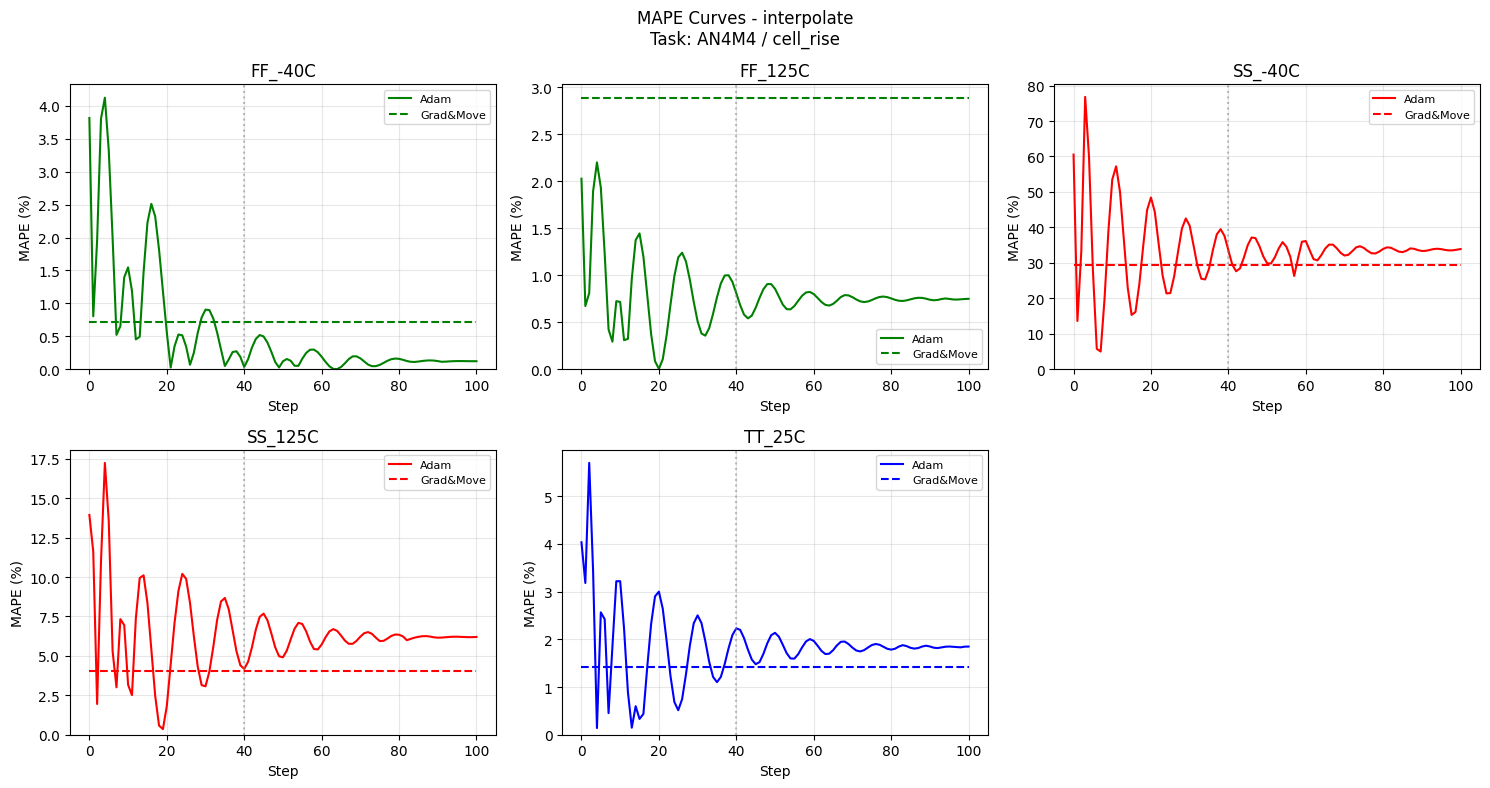

In [120]:
# ============================================================
# VISUALIZATION: MAPE CURVES
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

colors = {'FF': 'green', 'SS': 'red', 'TT': 'blue'}

for idx, (group_name, data) in enumerate(sorted(group_results.items())):
    ax = axes[idx]
    corner = group_name.split('_')[0]
    
    ax.plot(data['adam']['query_nrmses'], color=colors[corner], linewidth=1.5, label='Adam')
    ax.plot(data['grad_move']['query_nrmses'], color=colors[corner], linewidth=1.5, linestyle='--', label='Grad&Move')
    
    ax.axvline(x=40, color='gray', linestyle=':', alpha=0.5)
    ax.set_xlabel('Step')
    ax.set_ylabel('MAPE (%)')
    ax.set_title(f'{group_name}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)

# Remove empty subplot
axes[5].axis('off')

plt.suptitle(f'MAPE Curves - {SCENARIO}\nTask: {cell_key[0]} / {cell_key[1]}', fontsize=12)
plt.tight_layout()
plt.show()

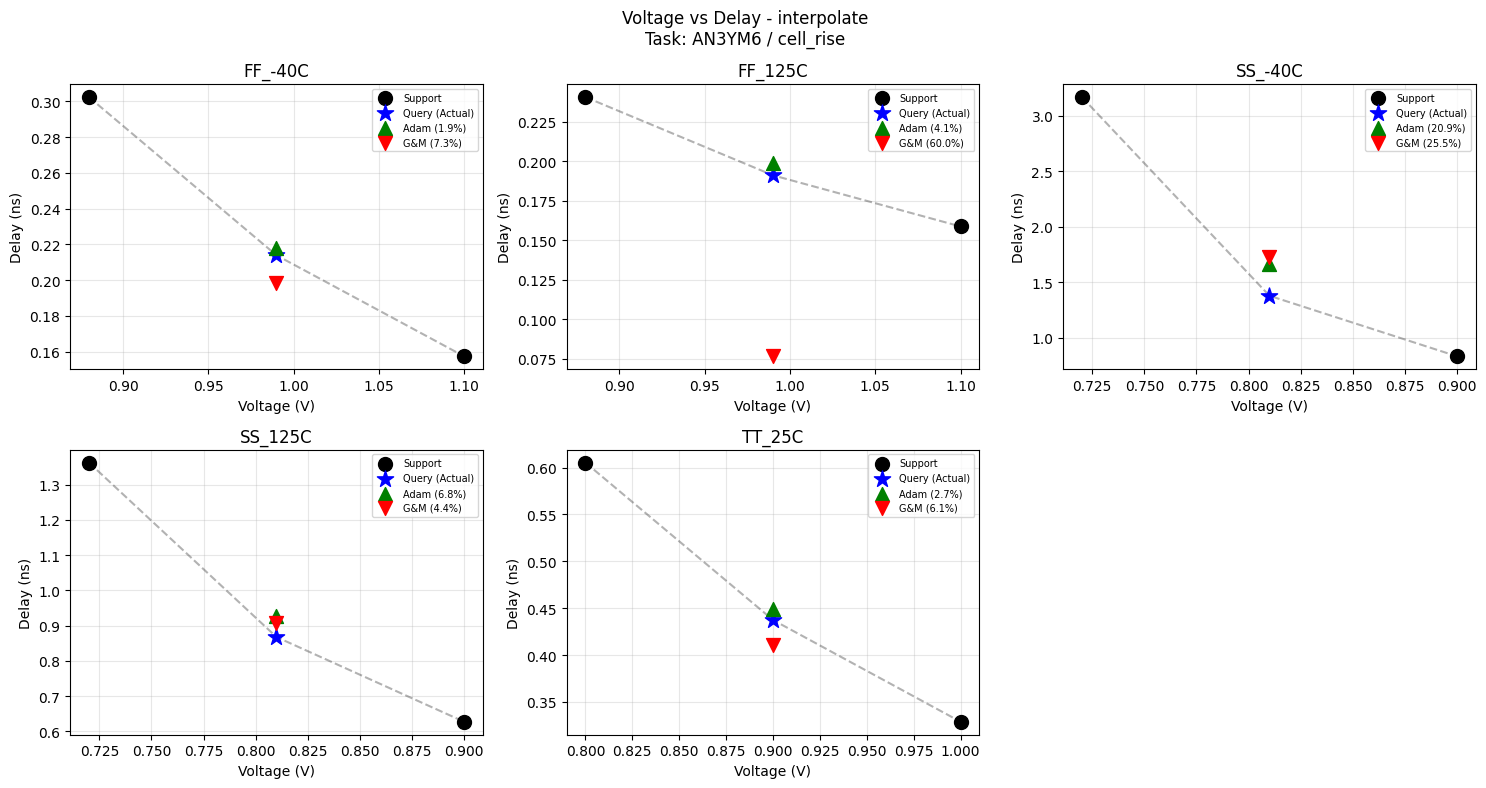

In [ ]:
# ============================================================
# VISUALIZATION: VOLTAGE vs DELAY CURVE
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, (group_name, data) in enumerate(sorted(group_results.items())):
    ax = axes[idx]
    corner = group_name.split('_')[0]
    
    # Support points
    support_v = [info['voltage'] for info in data['support_info']]
    support_d = [info['output'] for info in data['support_info']]
    
    # Query point (actual)
    query_v = data['query_info']['voltage']
    query_d = data['query_info']['output']
    
    # Predictions
    adam_pred = data['adam']['predictions_over_time'][40][0]
    gm_pred = data['grad_move']['predictions_over_time'][40][0]
    
    # Plot
    ax.scatter(support_v, support_d, s=100, c='black', marker='o', label='Support', zorder=5)
    ax.scatter([query_v], [query_d], s=150, c='blue', marker='*', label='Query (Actual)', zorder=5)
    ax.scatter([query_v], [adam_pred], s=100, c='green', marker='^', label=f'Adam ({abs(adam_pred-query_d)/query_d*100:.1f}%)', zorder=5)
    ax.scatter([query_v], [gm_pred], s=100, c='red', marker='v', label=f'G&M ({abs(gm_pred-query_d)/query_d*100:.1f}%)', zorder=5)
    
    # Connect with line
    all_v = support_v + [query_v]
    all_d = support_d + [query_d]
    sorted_idx = np.argsort(all_v)
    ax.plot([all_v[i] for i in sorted_idx], [all_d[i] for i in sorted_idx], 'k--', alpha=0.3)
    
    ax.set_xlabel('Voltage (V)')
    ax.set_ylabel('Delay (ns)')
    ax.set_title(f'{group_name}')
    ax.legend(fontsize=7, loc='best')
    ax.grid(True, alpha=0.3)

axes[5].axis('off')

plt.suptitle(f'Voltage vs Delay - {SCENARIO}\nTask: {cell_key[0]} / {cell_key[1]}', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# DETAILED RESULTS TABLE
# ============================================================

print("\n" + "=" * 100)
print(f"DETAILED RESULTS - {SCENARIO}")
print("=" * 100)

print(f"\n{'Group':<12} {'Support Voltages':<25} {'Query V':<10} {'Actual':<12} {'Adam':<12} {'G&M':<12} {'Adam %':<10} {'G&M %'}")
print("-" * 110)

for group_name, data in sorted(group_results.items()):
    support_v = ', '.join([f"{info['voltage']}V" for info in data['support_info']])
    query_v = data['query_info']['voltage']
    actual = data['query_info']['output']
    adam_pred = data['adam']['predictions_over_time'][40][0]
    gm_pred = data['grad_move']['predictions_over_time'][40][0]
    adam_err = abs(adam_pred - actual) / actual * 100
    gm_err = abs(gm_pred - actual) / actual * 100
    
    print(f"{group_name:<12} {support_v:<25} {query_v:<10.2f} {actual:<12.6f} {adam_pred:<12.6f} {gm_pred:<12.6f} {adam_err:<10.2f} {gm_err:.2f}")


DETAILED RESULTS - interpolate

Group        Support Voltages          Query V    Actual       Adam         G&M          Adam %     G&M %
--------------------------------------------------------------------------------------------------------------
FF_-40C      0.88V, 1.1V               0.99       0.213915     0.218015     0.198323     1.92       7.29
FF_125C      0.88V, 1.1V               0.99       0.191070     0.198973     0.076479     4.14       59.97
SS_-40C      0.72V, 0.9V               0.81       1.380070     1.668678     1.732316     20.91      25.52
SS_125C      0.72V, 0.9V               0.81       0.867552     0.926550     0.906010     6.80       4.43
TT_25C       0.8V, 1.0V                0.90       0.437419     0.449231     0.410890     2.70       6.06


In [ ]:
# ============================================================
# SUMMARY
# ============================================================

print("\n" + "=" * 80)
print(f"SUMMARY: Voltage Sweep ({SCENARIO})")
print("=" * 80)
print(f"\nTask: {cell_key[0]} / {cell_key[1]} / {cell_key[2]}")
print(f"Slew idx: {sl_key[0]}, Load idx: {sl_key[1]}")
print()

adam_mapes = [group_results[g]['adam']['query_mapes'][40] for g in group_results]
gm_mapes = [group_results[g]['grad_move']['query_mapes'][40] for g in group_results]

print(f"{'Method':<15} {'Mean MAPE':<15} {'Min':<15} {'Max':<15}")
print("-" * 60)
print(f"{'Adam':<15} {np.mean(adam_mapes):<15.2f} {np.min(adam_mapes):<15.2f} {np.max(adam_mapes):<15.2f}")
print(f"{'Grad&Move':<15} {np.mean(gm_mapes):<15.2f} {np.min(gm_mapes):<15.2f} {np.max(gm_mapes):<15.2f}")


SUMMARY: Voltage Sweep (interpolate)

Task: AN3YM6 / cell_rise / C
Slew idx: 6, Load idx: 1

Method          Mean MAPE       Min             Max            
------------------------------------------------------------
Adam            7.29            1.92            20.91          
Grad&Move       20.66           4.43            59.97          


In [ ]:
# ============================================================
# DIAGNOSE GRAD & MOVE FAILURE
# ============================================================

print("\n" + "=" * 100)
print("GRAD & MOVE DIAGNOSTIC")
print("=" * 100)

for group_name, data in sorted(group_results.items()):
    print(f"\n{group_name}:")
    
    # Get support data
    support_conds = [info['condition'] for info in data['support_info']]
    X_support_list = []
    y_support_list = []
    for cond in support_conds:
        inputs, outputs, metadata, c, voltage, t = all_data[cond]
        sample_idx = data_index[cell_key][cond][sl_key]
        X_support_list.append(inputs[sample_idx:sample_idx+1])
        y_support_list.append(outputs[sample_idx].item())
    
    X_support = torch.cat(X_support_list, dim=0).to(device)
    
    # Get model predictions
    with torch.no_grad():
        pred_support = maml_model.model.model(X_support).cpu().numpy().flatten()
    
    actual_support = np.array(y_support_list)
    
    print(f"  Actual support:  {actual_support}")
    print(f"  Model pred:      {pred_support}")
    print(f"  Actual order:    {np.argsort(actual_support)}")
    print(f"  Pred order:      {np.argsort(pred_support)}")
    print(f"  Order match:     {np.array_equal(np.argsort(actual_support), np.argsort(pred_support))}")
    print(f"  Correlation:     {np.corrcoef(actual_support, pred_support)[0,1]:.4f}")


GRAD & MOVE DIAGNOSTIC

FF_-40C:
  Actual support:  [0.30233401 0.15747599]
  Model pred:      [-0.46421006 -0.69685227]
  Actual order:    [1 0]
  Pred order:      [1 0]
  Order match:     True
  Correlation:     1.0000

FF_125C:
  Actual support:  [0.24058899 0.158683  ]
  Model pred:      [-0.44738826 -0.4785694 ]
  Actual order:    [1 0]
  Pred order:      [1 0]
  Order match:     True
  Correlation:     1.0000

SS_-40C:
  Actual support:  [3.16831994 0.83521301]
  Model pred:      [ 0.6265975  -0.40885878]
  Actual order:    [1 0]
  Pred order:      [1 0]
  Order match:     True
  Correlation:     1.0000

SS_125C:
  Actual support:  [1.36296999 0.62700099]
  Model pred:      [ 0.7324702  -0.42680728]
  Actual order:    [1 0]
  Pred order:      [1 0]
  Order match:     True
  Correlation:     1.0000

TT_25C:
  Actual support:  [0.60538602 0.328821  ]
  Model pred:      [-0.01999924 -0.6634302 ]
  Actual order:    [1 0]
  Pred order:      [1 0]
  Order match:     True
  Correlation